In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)
df = diabetes.frame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [2]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [4]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [5]:
df.dtypes

age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object

In [6]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [7]:
df.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='object')

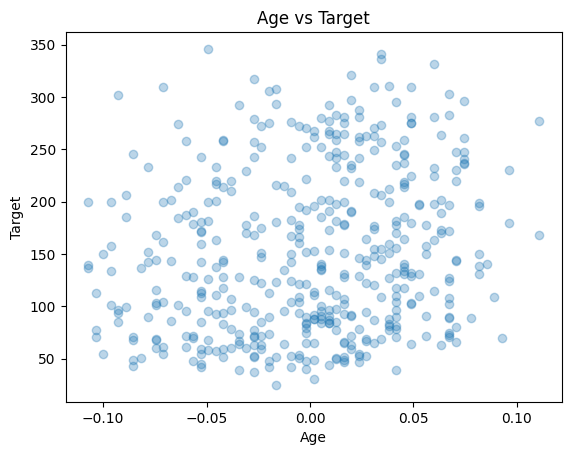

In [8]:
plt.scatter(df["age"], df["target"], alpha=0.3)
plt.xlabel("Age")
plt.ylabel("Target")
plt.title("Age vs Target")
plt.show()

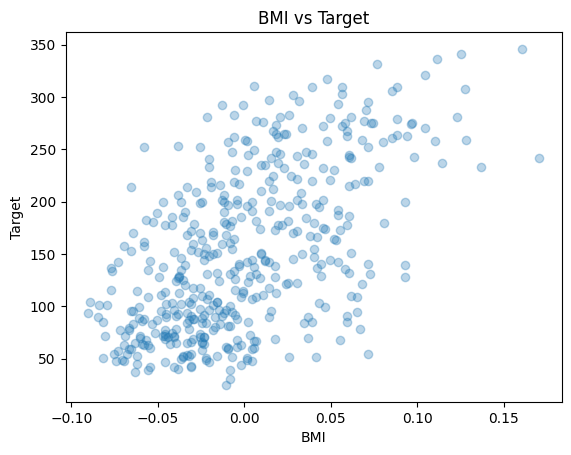

In [9]:
plt.scatter(df["bmi"], df["target"], alpha=0.3)
plt.xlabel("BMI")
plt.ylabel("Target")
plt.title("BMI vs Target")
plt.show()

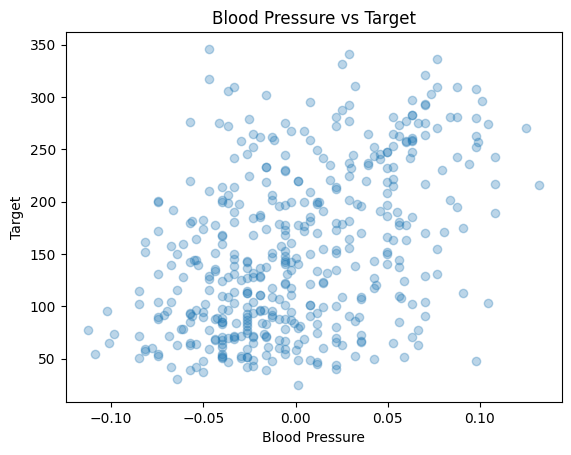

In [10]:
plt.scatter(df["bp"], df["target"], alpha=0.3)
plt.xlabel("Blood Pressure")
plt.ylabel("Target")
plt.title("Blood Pressure vs Target")
plt.show()

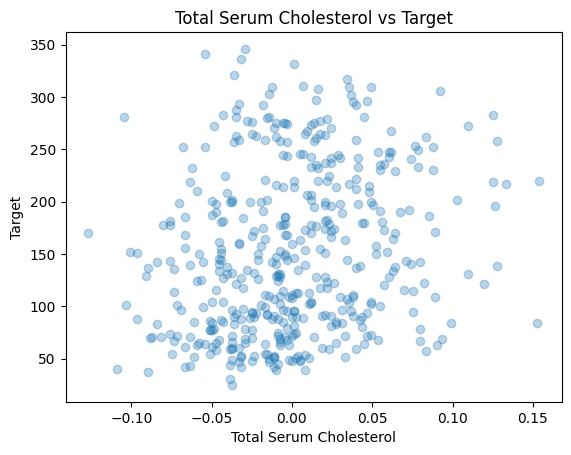

In [11]:
plt.scatter(df["s1"], df["target"], alpha=0.3)
plt.xlabel("Total Serum Cholesterol")
plt.ylabel("Target")
plt.title("Total Serum Cholesterol vs Target")
plt.show()

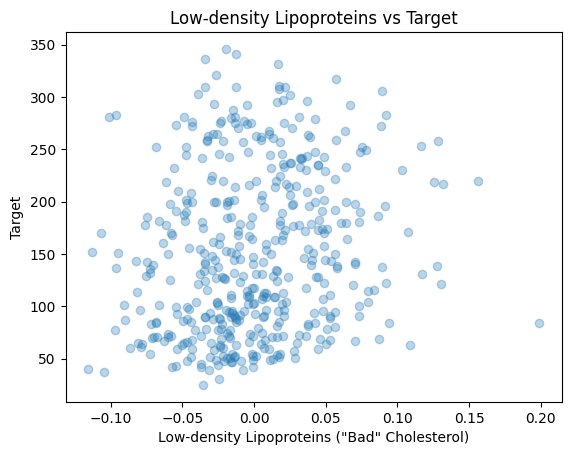

In [12]:
plt.scatter(df["s2"], df["target"], alpha=0.3)
plt.xlabel("Low-density Lipoproteins (\"Bad\" Cholesterol)")
plt.ylabel("Target")
plt.title("Low-density Lipoproteins vs Target")
plt.show()

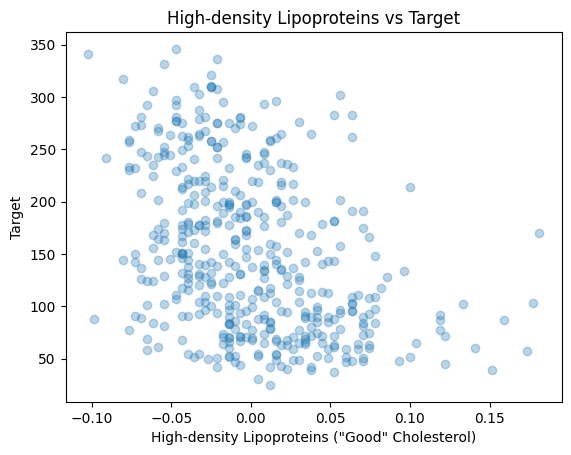

In [13]:
plt.scatter(df["s3"], df["target"], alpha=0.3)
plt.xlabel("High-density Lipoproteins (\"Good\" Cholesterol)")
plt.ylabel("Target")
plt.title("High-density Lipoproteins vs Target")
plt.show()

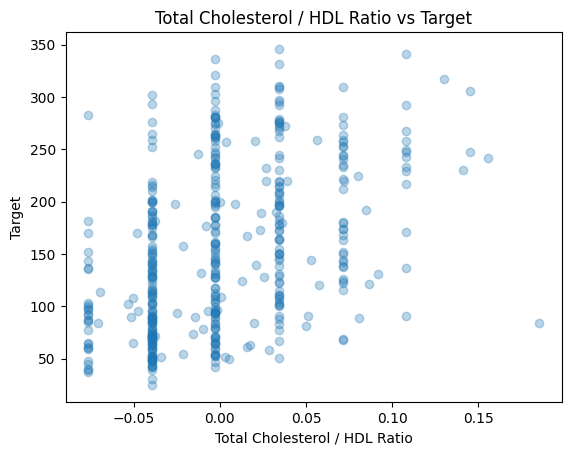

In [14]:
plt.scatter(df["s4"], df["target"], alpha=0.3)
plt.xlabel("Total Cholesterol / HDL Ratio")
plt.ylabel("Target")
plt.title("Total Cholesterol / HDL Ratio vs Target")
plt.show()

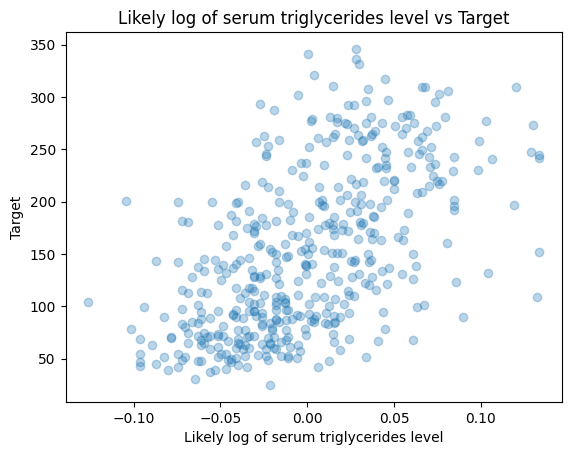

In [15]:
plt.scatter(df["s5"], df["target"], alpha=0.3)
plt.xlabel("Likely log of serum triglycerides level")
plt.ylabel("Target")
plt.title("Likely log of serum triglycerides level vs Target")
plt.show()

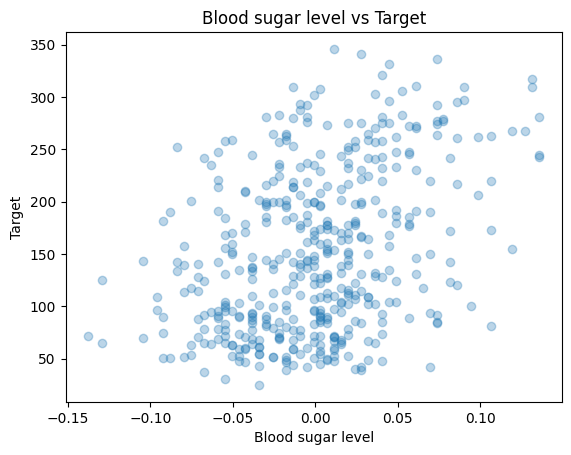

In [16]:
plt.scatter(df["s6"], df["target"], alpha=0.3)
plt.xlabel("Blood sugar level")
plt.ylabel("Target")
plt.title("Blood sugar level vs Target")
plt.show()

## Exploratory Analysis

**BMI vs Target**: This seems to have the strongest correlation and can end up as the dominant 
coefficient since there is a clear linear correlation.

**Log Triglycerides (s5) vs Target**: Also shows a strong linear correlation with a tight 
upward trend.

**Blood Pressure vs Target** and **Blood Sugar (s6) vs Target**: Both have an upward trend, 
however both graphs are more scattered and aren't as tightly grouped as BMI or log 
triglycerides.

**Age vs Target**: There doesn't seem to be any correlation at all since the data is scattered all 
over without any clear pattern.

**Total Cholesterol (s1) vs Target** and **LDL (s2) vs Target**: No clear correlation.

**HDL "Good" Cholesterol (s3) vs Target**: This scatterplot slopes downward, which makes sense because 
more "good" cholesterol being associated with less disease progression is a sensible real-world 
relationship.

**Cholesterol/HDL Ratio (s4) vs Target**: This plot looks odd with points clustering into 
distinct vertical stripes rather than a smooth scatter.

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["target"])
y = df["target"]
trainX, valX, trainY, valY = train_test_split(X,y, test_size = 0.25, random_state = 8)

model = LinearRegression()
model.fit(trainX, trainY)

for col, coef in zip(X.columns, model.coef_):
    print(f"{col}: {coef}")
print("Intercept:", model.intercept_)

age: 11.512266708440572
sex: -282.51443231408257
bmi: 534.2084846032255
bp: 401.73037118297344
s1: -1043.9046025858338
s2: 634.928910448298
s3: 186.43568421282862
s4: 204.94157943342685
s5: 762.4633608810134
s6: 91.95399832085594
Intercept: 152.5625670974632


In [18]:
df[["s1", "s2", "s3", "s4", "s5", "s6"]].corr()

,s1,s2,s3,s4,s5,s6
s1,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717
s2,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600
s3,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697
s4,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212
s5,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669
s6,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000


## Investigating Multicollinearity

The model's coefficients showed some surprising results compared to the EDA (Exploratory Data Analysis): s1 (total 
cholesterol) had the largest-magnitude coefficient (-1043.90) despite showing no visible 
correlation with the target in its scatter plot, and s3 (HDL) came out positive despite 
sloping downward against the target visually.

Checking the correlation matrix between the six blood serum features explains this. s1 and s2 
(LDL) are correlated at 0.897 which is very strong and makes sense since LDL is a major component 
of total cholesterol. s3 and s4 (cholesterol/HDL ratio) are correlated at -0.738, also strong, 
since s4 is calculated using HDL as part of its formula.

When input features are this strongly correlated with each other (not just with the target), 
the model will have trouble deciding how much credit to assign to each one individually, it can end 
up giving one feature an inflated coefficient and a correlated feature an opposing one, even 
though neither has a strong relationship with the target on its own.

In [19]:
val_preds = model.predict(valX)
val_mse = mean_squared_error(valY, val_preds)
val_rmse = np.sqrt(val_mse)
print("New Validation RMSE:", val_rmse)

New Validation RMSE: 55.749902518499354


In [ ]:
np.std(y)
# if validation RMSE is lower than the standard deviation of the target variable, it indicates that the model is performing well and capturing the underlying patterns in the data. In this case, the validation RMSE is lower than the standard deviation of the target variable, suggesting that the model is effective in predicting diabetes progression based on the given features.

np.float64(77.00574586945044)

## Evaluating Model Predictions

Testing out how well the model predicts vs. the actual values — specifically looking at 
whether points sit close to the red line, which would indicate accurate predictions.

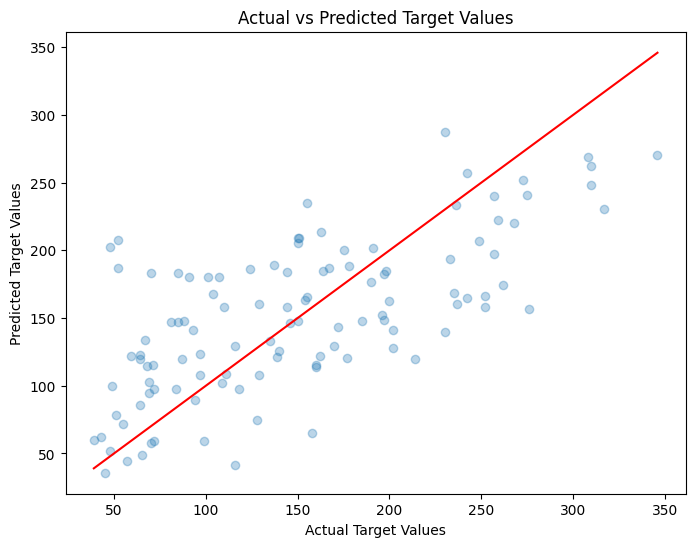

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(valY,val_preds, alpha=0.3)
plt.xlabel("Actual Target Values")
plt.ylabel("Predicted Target Values")
plt.title("Actual vs Predicted Target Values")
plt.plot([valY.min(), valY.max()], [valY.min(), valY.max()], color="red")
plt.show()

The model is a bit loose, as most points aren't tightly clustered near the red line. This is 
consistent with the validation RMSE of ~56 and the EDA findings earlier, several features 
(age, s1, s2) showed little to no correlation with the target, so it makes sense the model 
can't fit every point tightly.

In [29]:
new_person = pd.DataFrame({
    "age": [-0.05],
    "sex": [0.05],
    "bmi": [0.05],
    "bp": [0.07],
    "s1": [0.05],
    "s2": [0.02],
    "s3": [0.03],
    "s4": [0.04],
    "s5": [0.05],
    "s6": [0.06]
})

prediction = model.predict(new_person)
print(f"Prediction: {prediction[0]:,.2f}")

Prediction: 210.63


## Conclusion

This project used multiple linear regression to predict diabetes progression from 10 baseline 
patient measurements, using a dataset that was already standardized before being provided by 
scikit-learn.

**EDA**: The features that mattered most were BMI and log triglycerides (s5), both showing 
strong linear trends against the target. Blood pressure and blood sugar (s6) were also 
important, though not as strongly as the first two. Age, total cholesterol (s1), and LDL (s2) 
showed little to no visible correlation with the target.

**Multicollinearity**: s1 and s2 were highly correlated (0.897), meaning the model had a hard 
time differentiating their individual effects during prediction. This explained why s1 ended up 
with a surprisingly large coefficient despite showing no visible correlation with the target on 
its own.

**Model evaluation**: The final validation RMSE was 55.75, compared to the target's standard 
deviation of 77.01. Since RMSE is meaningfully lower than the std, this indicates the model is 
effectively capturing real patterns in the data rather than just predicting the average.

**Final prediction**: For a hypothetical patient with realistic scaled feature values, the model 
predicted a disease progression score of 210.63, which falls comfortably within the range of 
actual observed values.